Nguyễn Trọng Trúc - 2474802016707 - Lab2

In [4]:
#Giải nén
!unrar x DuLieu.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from DuLieu.rar

Creating    DuLieu                                                    OK
Extracting  DuLieu/04_CIGARET.xls                                          2%  OK 
Extracting  DuLieu/23_HOMES.xls                                           13%  OK 
Extracting  DuLieu/babies.txt                                             15%  OK 
Extracting  DuLieu/crabs.txt                                              20%  OK 
Extracting  DuLieu/dulieuxettuyendaihoc.csv                               28%  OK 
Extracting  DuLieu/heart_disease_dataset.csv                              33%  OK 
Extracting  DuLieu/patient_heart_rate.csv                                 34%  OK 
Extracting  DuLieu/processed_dulieuxettuyendaihoc.csv                     46%  OK 
Extracting  DuLieu/so2.JPG                                                51% 

**LAB 2: BÀI THỰC HÀNH TRÌNH BÀY DỮ LIỆU**

**Nội dung: Trực quan hóa dữ liệu điểm thi đã được xử lý processed_dulieuxettuyendaihoc.csv**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pandas.plotting import scatter_matrix

In [30]:
# Đọc file dữ liệu (thư mục Data chứa file processed_dulieuxettuyendaihoc.csv)
df = pd.read_csv('DuLieu/processed_dulieuxettuyendaihoc.csv')

In [31]:
# ==========================================================
# PHẦN 1: THỐNG KÊ DỮ LIỆU
# ==========================================================
print("\n" + "="*60)
print("PHẦN 1: THỐNG KÊ DỮ LIỆU")
print("="*60)


PHẦN 1: THỐNG KÊ DỮ LIỆU


In [32]:
# Câu 1: Hãy sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần
print("\n--- Câu 1: Sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần ---")
dh1_tang_dan = df.sort_values(by='DH1')
print(dh1_tang_dan[['DH1']].head(10))


--- Câu 1: Sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần ---
     DH1
53  1.00
43  1.25
5   1.50
72  1.50
83  1.75
87  1.75
38  2.00
12  2.00
79  2.00
73  2.00


In [33]:
# Câu 2: Hãy sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính
print("\n--- Câu 2: Sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính (GT) ---")
dh2_theo_gt = df.sort_values(by=['GT', 'DH2'])
print(dh2_theo_gt[['GT', 'DH2']].head(10))

# Hàm hỗ trợ tính Q1, Q2, Q3 dùng chung cho câu 3, 4, 5
def q1(x): return x.quantile(0.25)
def q2(x): return x.quantile(0.50)
def q3(x): return x.quantile(0.75)
cac_phep_tinh = ['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q2, q3]


--- Câu 2: Sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính (GT) ---
   GT   DH2
95  F  1.50
25  F  2.00
24  F  2.25
46  F  2.25
13  F  2.75
21  F  3.00
0   F  3.25
51  F  3.25
8   F  3.50
22  F  3.50


In [34]:
# Câu 3: Pivot-table thống kê count, sum, mean, median, min, max, std, Q1, Q2, Q3 của DH1 theo KT
print("\n--- Câu 3: Pivot-table thống kê DH1 theo KT ---")
pivot_cau3 = df.pivot_table(values='DH1', index='KT', aggfunc=cac_phep_tinh)
pivot_cau3.columns = ['count', 'max', 'mean', 'median', 'min', 'std', 'sum', 'Q1', 'Q2', 'Q3']
print(pivot_cau3)


--- Câu 3: Pivot-table thống kê DH1 theo KT ---
    count     max      mean  median   min   std       sum      Q1    Q2     Q3
KT                                                                            
A      49  163.50  3.336735    3.25  1.00  6.50  1.274296  2.2500  3.25  4.250
A1      6   17.50  2.916667    3.00  2.00  4.25  0.861201  2.1875  3.00  3.250
B       9   29.50  3.277778    3.50  1.75  4.50  0.823905  3.2500  3.50  3.750
C      14   79.25  5.660714    5.25  4.75  7.00  0.812209  5.0625  5.25  6.375
D1     22   84.25  3.829545    3.75  1.25  6.75  1.370146  3.0000  3.75  4.875


In [35]:
# Câu 4: Pivot-table thống kê DH1 theo KT và KV
print("\n--- Câu 4: Pivot-table thống kê DH1 theo KT và KV ---")
pivot_cau4 = df.pivot_table(values='DH1', index=['KT', 'KV'], aggfunc=cac_phep_tinh)
pivot_cau4.columns = ['count', 'max', 'mean', 'median', 'min', 'std', 'sum', 'Q1', 'Q2', 'Q3']
print(pivot_cau4)


--- Câu 4: Pivot-table thống kê DH1 theo KT và KV ---
        count    max      mean  median   min   std       sum      Q1     Q2  \
KT KV                                                                         
A  1       29  93.75  3.232759   3.250  1.00  6.50  1.369194  2.0000  3.250   
   2        9  31.75  3.527778   3.500  2.00  6.25  1.427653  2.2500  3.500   
   2NT     11  38.00  3.454545   3.500  2.00  4.75  0.913908  2.8750  3.500   
A1 1        2   4.75  2.375000   2.375  2.00  2.75  0.530330  2.1875  2.375   
   2NT      4  12.75  3.187500   3.250  2.00  4.25  0.921389  2.9375  3.250   
B  1        8  25.75  3.218750   3.375  1.75  4.50  0.860207  3.0000  3.375   
   2NT      1   3.75  3.750000   3.750  3.75  3.75       NaN  3.7500  3.750   
C  1        8  43.50  5.437500   5.250  4.75  7.00  0.728869  5.0000  5.250   
   2        2  11.50  5.750000   5.750  5.00  6.50  1.060660  5.3750  5.750   
   2NT      4  24.25  6.062500   6.000  5.25  7.00  0.943729  5.2500  6.000 

In [36]:
# Câu 5: Pivot-table thống kê DH1 theo KT, KV và DT
print("\n--- Câu 5: Pivot-table thống kê DH1 theo KT, KV và DT ---")
pivot_cau5 = df.pivot_table(values='DH1', index=['KT', 'KV', 'DT'], aggfunc=cac_phep_tinh)
pivot_cau5.columns = ['count', 'max', 'mean', 'median', 'min', 'std', 'sum', 'Q1', 'Q2', 'Q3']
print(pivot_cau5)


--- Câu 5: Pivot-table thống kê DH1 theo KT, KV và DT ---
            count    max      mean  median   min   std       sum      Q1  \
KT KV  DT                                                                  
A  1   0.0     29  93.75  3.232759   3.250  1.00  6.50  1.369194  2.0000   
   2   0.0      8  27.50  3.437500   3.000  2.00  6.25  1.498511  2.2500   
       6.0      1   4.25  4.250000   4.250  4.25  4.25       NaN  4.2500   
   2NT 0.0     11  38.00  3.454545   3.500  2.00  4.75  0.913908  2.8750   
A1 1   0.0      2   4.75  2.375000   2.375  2.00  2.75  0.530330  2.1875   
   2NT 0.0      4  12.75  3.187500   3.250  2.00  4.25  0.921389  2.9375   
B  1   0.0      8  25.75  3.218750   3.375  1.75  4.50  0.860207  3.0000   
   2NT 0.0      1   3.75  3.750000   3.750  3.75  3.75       NaN  3.7500   
C  1   0.0      8  43.50  5.437500   5.250  4.75  7.00  0.728869  5.0000   
   2   0.0      2  11.50  5.750000   5.750  5.00  6.50  1.060660  5.3750   
   2NT 0.0      4  24.25  6.0

In [37]:
# ==========================================================
# PHẦN 2: TRÌNH BÀY DỮ LIỆU
# ==========================================================
print("\n" + "="*60)
print("PHẦN 2: TRÌNH BÀY DỮ LIỆU")
print("="*60)


PHẦN 2: TRÌNH BÀY DỮ LIỆU



--- Câu 1: Trình bày dữ liệu biến GT (Giới tính) ---
    Tan so  Tan suat (%)
GT                      
M       52          52.0
F       48          48.0


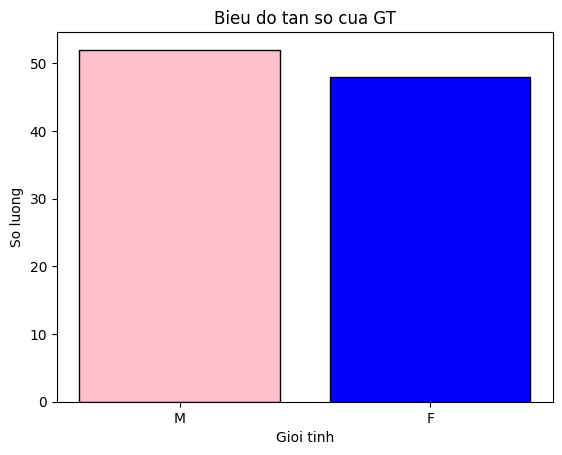

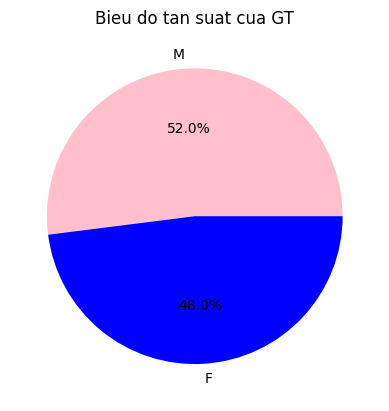

In [38]:
# Câu 1: Hãy trình bày dữ liệu biến GT (Gợi ý: bảng tần số/tần suất, biểu đồ cột & tròn)
print("\n--- Câu 1: Trình bày dữ liệu biến GT (Giới tính) ---")
tan_so_gt = df['GT'].value_counts()
tan_suat_gt = df['GT'].value_counts(normalize=True) * 100

bang_gt = pd.DataFrame({'Tan so': tan_so_gt, 'Tan suat (%)': tan_suat_gt})
print(bang_gt)

plt.bar(tan_so_gt.index, tan_so_gt.values, color=['pink', 'blue'], edgecolor='black')
plt.title("Bieu do tan so cua GT")
plt.xlabel("Gioi tinh")
plt.ylabel("So luong")
plt.show()

plt.pie(tan_suat_gt.values, labels=tan_suat_gt.index, autopct='%1.1f%%', colors=['pink', 'blue'])
plt.title("Bieu do tan suat cua GT")
plt.show()


--- Câu 2: Trình bày dữ liệu các biến US_TBM1, US_TBM2, US_TBM3 ---
          US_TBM1     US_TBM2    US_TBM3
count  100.000000  100.000000  100.00000
mean     2.434480    2.559600    2.67176
std      0.391203    0.377656    0.29981
min      1.616000    1.768000    1.91600
25%      2.107000    2.223000    2.47300
50%      2.480000    2.588000    2.70600
75%      2.724000    2.893000    2.87400
max      3.232000    3.416000    3.31600


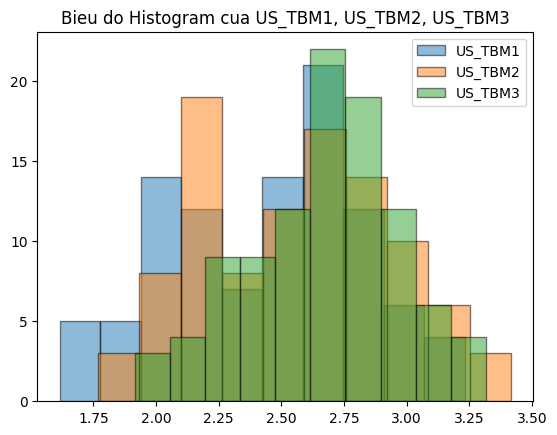

In [39]:
# Câu 2: Hãy trình bày dữ liệu lần lượt các biến US_TBM1, US_TBM2 và US_TBM3
print("\n--- Câu 2: Trình bày dữ liệu các biến US_TBM1, US_TBM2, US_TBM3 ---")
if 'US_TBM1' not in df.columns:
    df['US_TBM1'] = df['T1'] / 2.5
    df['US_TBM2'] = df['L1'] / 2.5 if 'L1' in df.columns else df['T1'] / 2.5
    df['US_TBM3'] = df['H1'] / 2.5 if 'H1' in df.columns else df['T1'] / 2.5

print(df[['US_TBM1', 'US_TBM2', 'US_TBM3']].describe())

plt.hist(df['US_TBM1'], alpha=0.5, label='US_TBM1', edgecolor='black')
plt.hist(df['US_TBM2'], alpha=0.5, label='US_TBM2', edgecolor='black')
plt.hist(df['US_TBM3'], alpha=0.5, label='US_TBM3', edgecolor='black')
plt.title("Bieu do Histogram cua US_TBM1, US_TBM2, US_TBM3")
plt.legend()
plt.show()


--- Câu 3: Trình bày dữ liệu biến DT với các học sinh là nam ---
     Tan so  Tan suat (%)
DT                       
0.0      50     96.153846
1.0       1      1.923077
6.0       1      1.923077


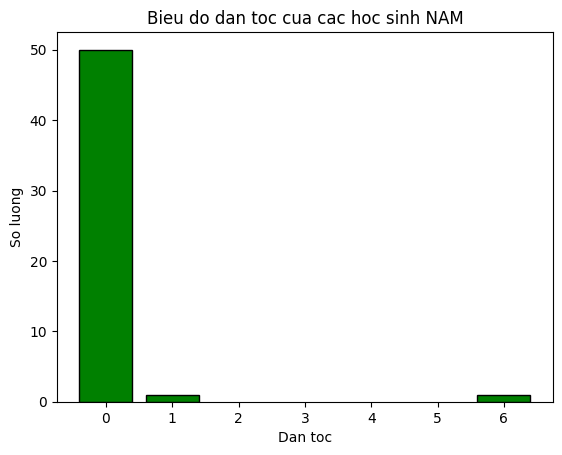

In [40]:
# Câu 3: Hãy trình bày dữ liệu biến DT với các học sinh là nam
print("\n--- Câu 3: Trình bày dữ liệu biến DT với các học sinh là nam ---")
hoc_sinh_nam = df[df['GT'] == 'M']
tan_so_dt_nam = hoc_sinh_nam['DT'].value_counts()
tan_suat_dt_nam = hoc_sinh_nam['DT'].value_counts(normalize=True) * 100

bang_dt_nam = pd.DataFrame({'Tan so': tan_so_dt_nam, 'Tan suat (%)': tan_suat_dt_nam})
print(bang_dt_nam)

plt.bar(tan_so_dt_nam.index, tan_so_dt_nam.values, color='green', edgecolor='black')
plt.title("Bieu do dan toc cua cac hoc sinh NAM")
plt.xlabel("Dan toc")
plt.ylabel("So luong")
plt.show()

In [41]:
# Câu 4: Hãy trình bày dữ liệu biến KV với học sinh nam, dân tộc Kinh, DH1>=5.0, DH2>=4.0, DH3>=4.0
print("\n--- Câu 4: Trình bày dữ liệu biến KV (nam, dân tộc Kinh, DH1>=5.0, DH2>=4.0, DH3>=4.0) ---")
dieu_kien_cau4 = (df['GT'] == 'M') & \
                  ((df['DT'] == 1) | (df['DT'] == 'Kinh')) & \
                  (df['DH1'] >= 5.0) & \
                  (df['DH2'] >= 4.0) & \
                  (df['DH3'] >= 4.0)

df_loc_cau4 = df[dieu_kien_cau4]
tan_so_kv = df_loc_cau4['KV'].value_counts()
tan_suat_kv = df_loc_cau4['KV'].value_counts(normalize=True) * 100

bang_kv_loc = pd.DataFrame({'Tan so': tan_so_kv, 'Tan suat (%)': tan_suat_kv})
print(bang_kv_loc)

if not tan_so_kv.empty:
    plt.bar(tan_so_kv.index, tan_so_kv.values, color='orange', edgecolor='black')
    plt.title("Phan bo Khu vuc (KV) cua hoc sinh nam dat chuan")
    plt.xlabel("Khu vuc")
    plt.ylabel("So luong")
    plt.show()


--- Câu 4: Trình bày dữ liệu biến KV (nam, dân tộc Kinh, DH1>=5.0, DH2>=4.0, DH3>=4.0) ---
Empty DataFrame
Columns: [Tan so, Tan suat (%)]
Index: []



--- Câu 5: Trình bày dữ liệu DH1, DH2, DH3 (>=5.0) thuộc khu vực 2NT ---

Biến DH1 >= 5.0 thuộc khu vực 2NT:
count    4.000000
mean     6.062500
std      0.943729
min      5.250000
25%      5.250000
50%      6.000000
75%      6.812500
max      7.000000
Name: DH1, dtype: float64


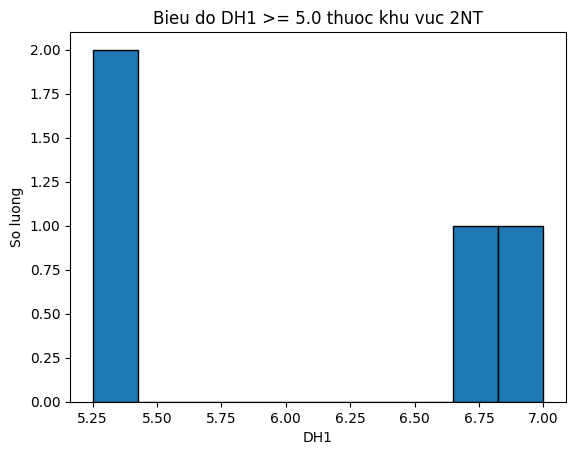


Biến DH2 >= 5.0 thuộc khu vực 2NT:
count    6.000000
mean     5.750000
std      1.129159
min      5.000000
25%      5.250000
50%      5.250000
75%      5.625000
max      8.000000
Name: DH2, dtype: float64


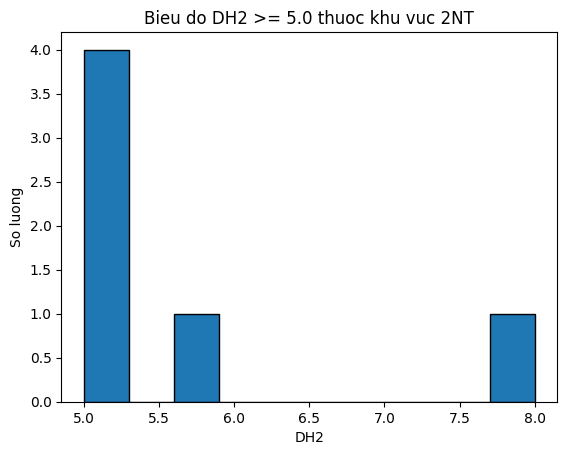


Biến DH3 >= 5.0 thuộc khu vực 2NT:
count    6.000000
mean     5.750000
std      0.689202
min      5.000000
25%      5.125000
50%      5.750000
75%      6.375000
max      6.500000
Name: DH3, dtype: float64


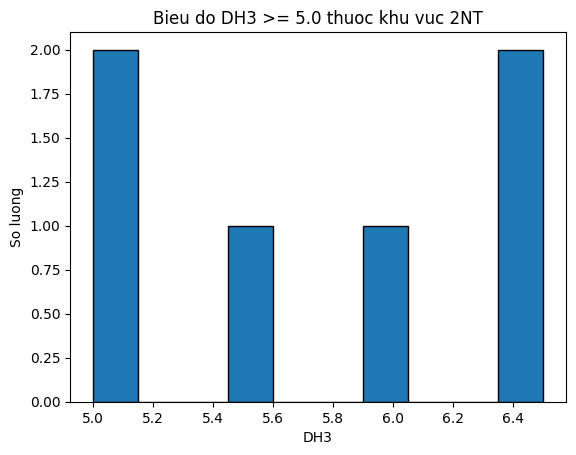

In [42]:
# Câu 5: Hãy trình bày dữ liệu lần lượt các biến DH1, DH2, DH3 >= 5.0 và thuộc khu vực 2NT
print("\n--- Câu 5: Trình bày dữ liệu DH1, DH2, DH3 (>=5.0) thuộc khu vực 2NT ---")
df_kv2nt = df[df['KV'] == '2NT'] if df['KV'].dtype == object else df[df['KV'].astype(str) == '2NT']
for col in ['DH1', 'DH2', 'DH3']:
    du_lieu_loc = df_kv2nt[df_kv2nt[col] >= 5.0][col]
    print(f"\nBiến {col} >= 5.0 thuộc khu vực 2NT:")
    print(du_lieu_loc.describe())
    if not du_lieu_loc.empty:
        plt.hist(du_lieu_loc, bins=10, edgecolor='black')
        plt.title(f"Bieu do {col} >= 5.0 thuoc khu vuc 2NT")
        plt.xlabel(col)
        plt.ylabel("So luong")
        plt.show()

In [43]:
# ==========================================================
# PHẦN 3: TRỰC QUAN HÓA DỮ LIỆU THEO NHÓM PHÂN LOẠI
# ==========================================================
print("\n" + "="*60)
print("PHẦN 3: TRỰC QUAN HÓA DỮ LIỆU THEO NHÓM PHÂN LOẠI")
print("="*60)


PHẦN 3: TRỰC QUAN HÓA DỮ LIỆU THEO NHÓM PHÂN LOẠI


In [44]:
# Chuẩn bị: tạo trước các cột phân lớp XL1, XL2, XL3 và KQXT nếu file chưa có sẵn
if 'XL1' not in df.columns:
    df['XL1'] = pd.cut(df['T1'], bins=[0, 5, 6.5, 8, 9, 10], labels=['Y', 'TB', 'K', 'G', 'XS'])
    df['XL2'] = pd.cut(df['L1'], bins=[0, 5, 6.5, 8, 9, 10], labels=['Y', 'TB', 'K', 'G', 'XS']) if 'L1' in df.columns else df['XL1']
    df['XL3'] = pd.cut(df['H1'], bins=[0, 5, 6.5, 8, 9, 10], labels=['Y', 'TB', 'K', 'G', 'XS']) if 'H1' in df.columns else df['XL1']

if 'KQXT' not in df.columns:
    # Giả sử điều kiện đậu là điểm trung bình các môn DH >= 5.0
    diem_tb_dh = (df['DH1'] + df['DH2'] + df['DH3']) / 3
    df['KQXT'] = diem_tb_dh.apply(lambda x: 'Dau' if x >= 5.0 else 'Rot')


--- Câu 1: Trực quan xếp loại học sinh nữ trên các nhóm XL1, XL2, XL3 (unstacked) ---


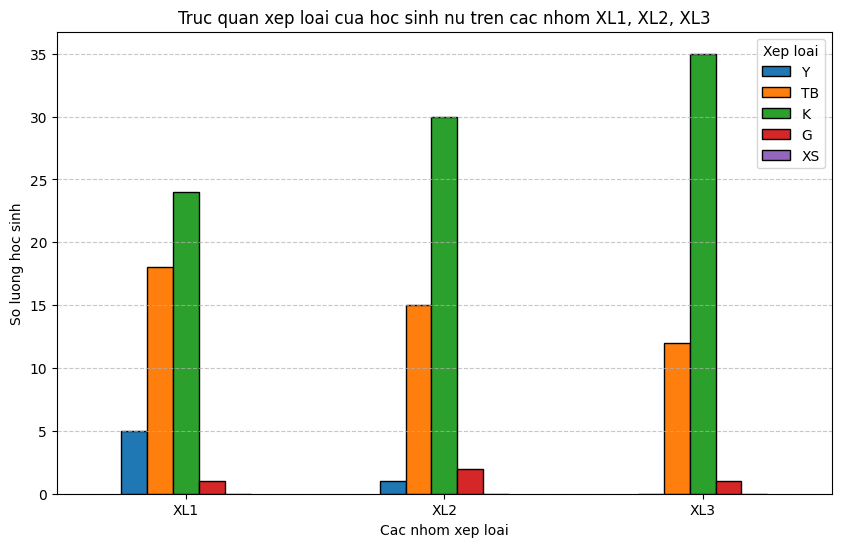

In [45]:
# Câu 1: Trực quan dữ liệu học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked
print("\n--- Câu 1: Trực quan xếp loại học sinh nữ trên các nhóm XL1, XL2, XL3 (unstacked) ---")
df_nu = df[df['GT'] == 'F']

data_xl1 = df_nu['XL1'].value_counts().reindex(['Y', 'TB', 'K', 'G', 'XS'], fill_value=0)
data_xl2 = df_nu['XL2'].value_counts().reindex(['Y', 'TB', 'K', 'G', 'XS'], fill_value=0)
data_xl3 = df_nu['XL3'].value_counts().reindex(['Y', 'TB', 'K', 'G', 'XS'], fill_value=0)

df_xl_tonghop = pd.DataFrame({'XL1': data_xl1, 'XL2': data_xl2, 'XL3': data_xl3}).T

df_xl_tonghop.plot(kind='bar', figsize=(10, 6), edgecolor='black')
plt.title("Truc quan xep loai cua hoc sinh nu tren cac nhom XL1, XL2, XL3")
plt.xlabel("Cac nhom xep loai")
plt.ylabel("So luong hoc sinh")
plt.xticks(rotation=0)
plt.legend(title="Xep loai")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


--- Câu 2: Trực quan KQXT nhóm khối thi A, A1, B thuộc khu vực 1, 2 ---


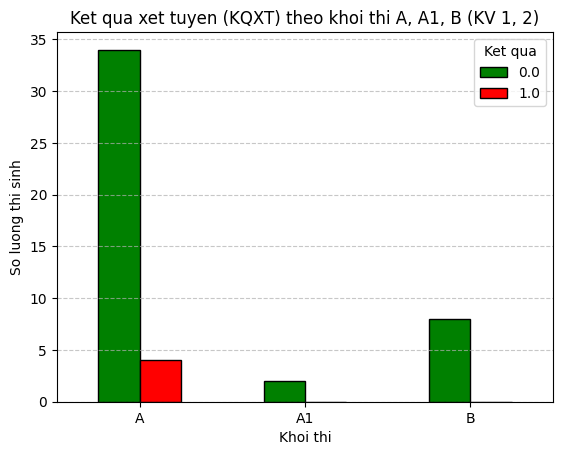

In [46]:
# Câu 2: Trực quan KQXT trên nhóm học sinh khối thi A, A1, B thuộc khu vực 1, 2
print("\n--- Câu 2: Trực quan KQXT nhóm khối thi A, A1, B thuộc khu vực 1, 2 ---")
dieu_kien_cau2 = df['KT'].isin(['A', 'A1', 'B']) & df['KV'].isin(['1', '2', 1, 2])
df_cau2 = df[dieu_kien_cau2]

df_cau2.groupby('KT')['KQXT'].value_counts().unstack().fillna(0).plot(kind='bar', edgecolor='black', color=['green', 'red'])
plt.title("Ket qua xet tuyen (KQXT) theo khoi thi A, A1, B (KV 1, 2)")
plt.xlabel("Khoi thi")
plt.ylabel("So luong thi sinh")
plt.xticks(rotation=0)
plt.legend(title="Ket qua")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


--- Câu 3: Trực quan số lượng thí sinh từng khu vực theo từng nhóm khối thi ---


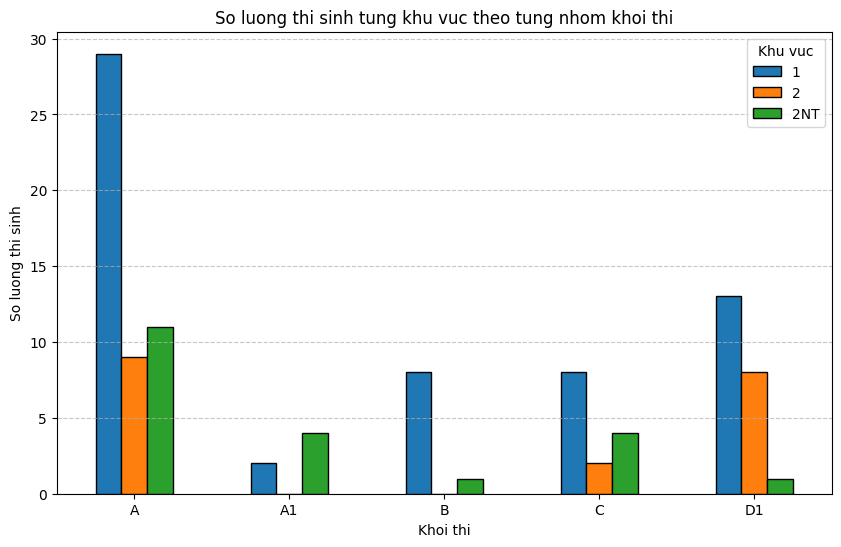

In [47]:
# Câu 3: Trực quan số lượng thí sinh từng khu vực dựa trên từng nhóm khối thi
print("\n--- Câu 3: Trực quan số lượng thí sinh từng khu vực theo từng nhóm khối thi ---")
df.groupby('KT')['KV'].value_counts().unstack().fillna(0).plot(kind='bar', figsize=(10, 6), edgecolor='black')
plt.title("So luong thi sinh tung khu vuc theo tung nhom khoi thi")
plt.xlabel("Khoi thi")
plt.ylabel("So luong thi sinh")
plt.xticks(rotation=0)
plt.legend(title="Khu vuc")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


--- Câu 4: Trực quan số lượng thí sinh Đậu/Rớt theo từng nhóm khối thi ---


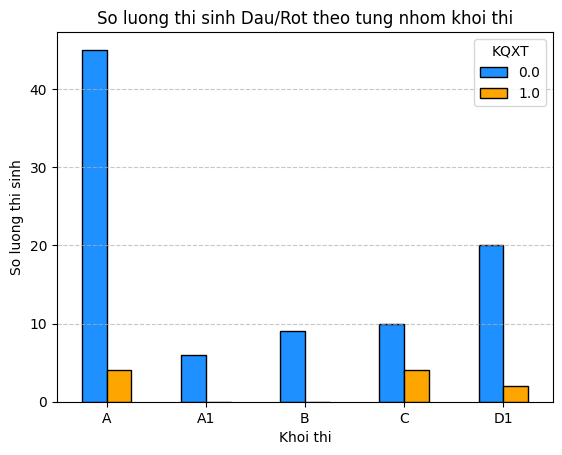

In [48]:
# Câu 4: Trực quan số lượng thí sinh đậu, rớt trên từng nhóm khối thi
print("\n--- Câu 4: Trực quan số lượng thí sinh Đậu/Rớt theo từng nhóm khối thi ---")
df.groupby('KT')['KQXT'].value_counts().unstack().fillna(0).plot(kind='bar', edgecolor='black', color=['dodgerblue', 'orange'])
plt.title("So luong thi sinh Dau/Rot theo tung nhom khoi thi")
plt.xlabel("Khoi thi")
plt.ylabel("So luong thi sinh")
plt.xticks(rotation=0)
plt.legend(title="KQXT")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


--- Câu 5: Trực quan số lượng thí sinh Đậu/Rớt theo từng nhóm khu vực ---


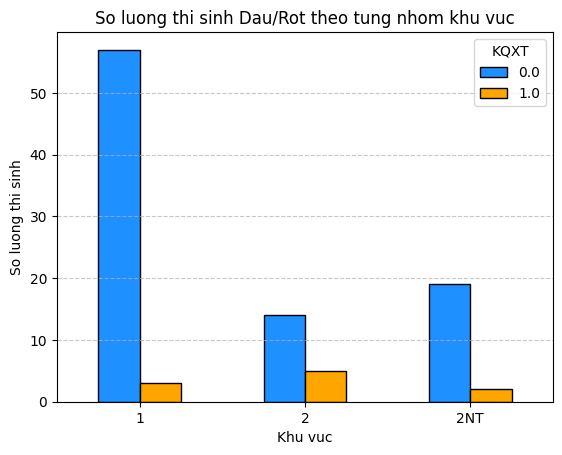

In [49]:
# Câu 5: Trực quan số lượng thí sinh đậu rớt trên từng nhóm khu vực
print("\n--- Câu 5: Trực quan số lượng thí sinh Đậu/Rớt theo từng nhóm khu vực ---")
df.groupby('KV')['KQXT'].value_counts().unstack().fillna(0).plot(kind='bar', edgecolor='black', color=['dodgerblue', 'orange'])
plt.title("So luong thi sinh Dau/Rot theo tung nhom khu vuc")
plt.xlabel("Khu vuc")
plt.ylabel("So luong thi sinh")
plt.xticks(rotation=0)
plt.legend(title="KQXT")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


--- Câu 6: Trực quan số lượng thí sinh Đậu/Rớt theo từng nhóm dân tộc ---


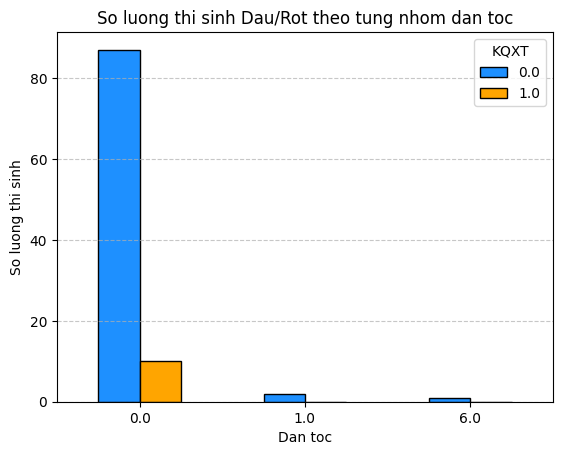

In [50]:
# Câu 6: Trực quan số lượng thí sinh đậu rớt dựa trên từng nhóm dân tộc
print("\n--- Câu 6: Trực quan số lượng thí sinh Đậu/Rớt theo từng nhóm dân tộc ---")
df.groupby('DT')['KQXT'].value_counts().unstack().fillna(0).plot(kind='bar', edgecolor='black', color=['dodgerblue', 'orange'])
plt.title("So luong thi sinh Dau/Rot theo tung nhom dan toc")
plt.xlabel("Dan toc")
plt.ylabel("So luong thi sinh")
plt.xticks(rotation=0)
plt.legend(title="KQXT")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


--- Câu 7: Trực quan số lượng thí sinh Đậu/Rớt theo từng nhóm giới tính ---


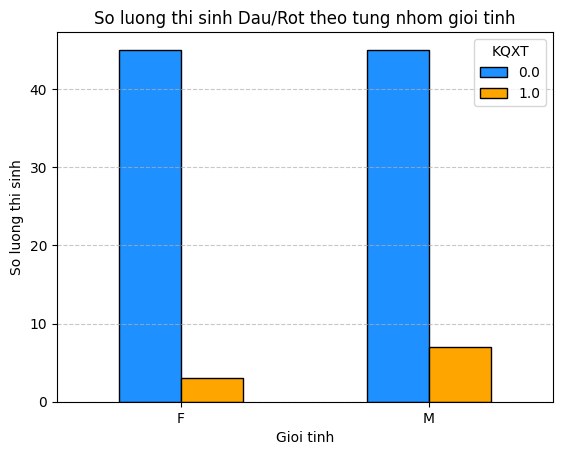

In [51]:

# Câu 7: Trực quan số lượng thí sinh đậu rớt dựa trên từng nhóm giới tính
print("\n--- Câu 7: Trực quan số lượng thí sinh Đậu/Rớt theo từng nhóm giới tính ---")
df.groupby('GT')['KQXT'].value_counts().unstack().fillna(0).plot(kind='bar', edgecolor='black', color=['dodgerblue', 'orange'])
plt.title("So luong thi sinh Dau/Rot theo tung nhom gioi tinh")
plt.xlabel("Gioi tinh")
plt.ylabel("So luong thi sinh")
plt.xticks(rotation=0)
plt.legend(title="KQXT")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [52]:
# ==========================================================
# PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU NÂNG CAO
# ==========================================================
print("\n" + "="*60)
print("PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU NÂNG CAO")
print("="*60)


PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU NÂNG CAO



--- Câu 1: Biểu đồ đường Simple cho biến T1 ---


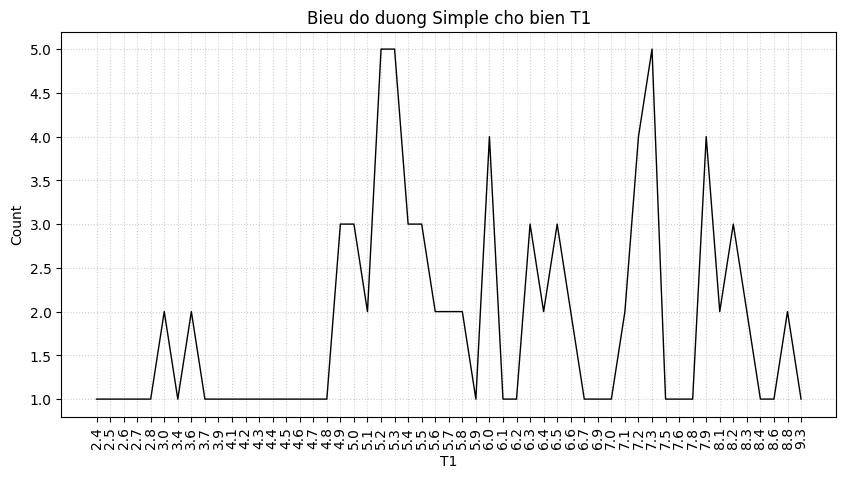

In [53]:
# Câu 1: Vẽ biểu đồ đường Simple cho biến T1
print("\n--- Câu 1: Biểu đồ đường Simple cho biến T1 ---")
thong_ke_t1 = df['T1'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(thong_ke_t1.index.astype(str), thong_ke_t1.values, color='black', linewidth=1)
plt.title("Bieu do duong Simple cho bien T1")
plt.xlabel("T1")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [54]:
# Câu 2: Tạo biến phân loại (phanlopt1) cho môn Toán (T1)
# Quy định: <5: kém (k), 5->7: trung bình (tb), 7->8: khá (kh), >=8: giỏi (g)
print("\n--- Câu 2: Tạo biến phân loại phanlopt1 cho T1 ---")
df['phanlopt1'] = pd.cut(df['T1'], bins=[0, 5, 7, 8, 10], right=False, labels=['k', 'tb', 'kh', 'g'])
print(df[['T1', 'phanlopt1']].head(10))


--- Câu 2: Tạo biến phân loại phanlopt1 cho T1 ---
    T1 phanlopt1
0  7.2        kh
1  5.4        tb
2  5.6        tb
3  6.6        tb
4  6.0        tb
5  9.3         g
6  2.8         k
7  8.3         g
8  6.5        tb
9  7.3        kh


In [55]:
# Câu 3: Lập bảng tần số cho biến phanloait1
print("\n--- Câu 3: Bảng tần số cho biến phanloait1 ---")
bang_tan_so_phanloai = df['phanlopt1'].value_counts().reindex(['k', 'tb', 'kh', 'g'], fill_value=0)
print(bang_tan_so_phanloai)


--- Câu 3: Bảng tần số cho biến phanloait1 ---
phanlopt1
k     23
tb    46
kh    19
g     12
Name: count, dtype: int64



--- Câu 4: Biểu đồ đường Multiple Line cho T1 theo phanlopt1 ---


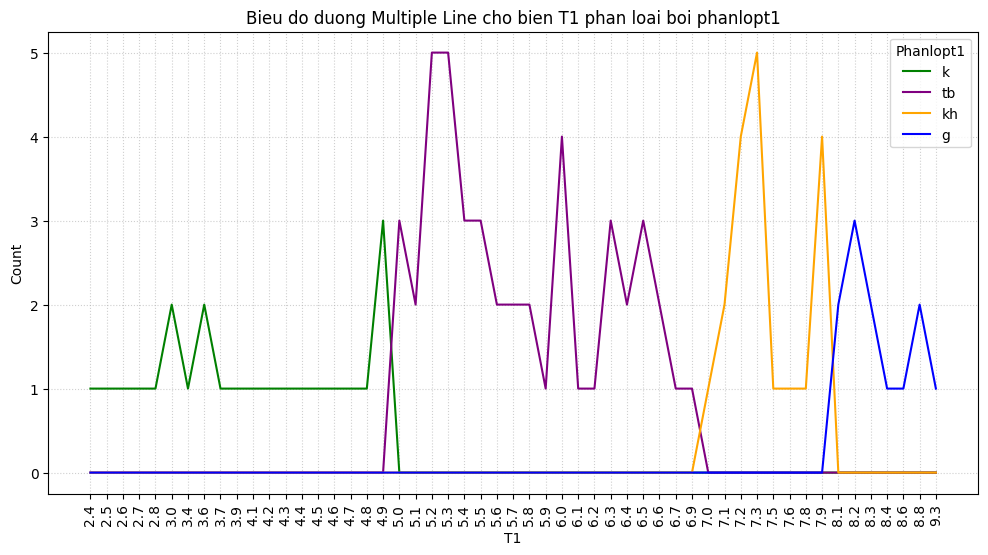

In [56]:
# Câu 4: Vẽ biểu đồ đường Multiple Line cho biến T1 phân loại bởi phanlopt1
print("\n--- Câu 4: Biểu đồ đường Multiple Line cho T1 theo phanlopt1 ---")
plt.figure(figsize=(12, 6))
mau_sac = {'k': 'green', 'tb': 'purple', 'kh': 'orange', 'g': 'blue'}
for nhom in ['k', 'tb', 'kh', 'g']:
    df_nhom = df[df['phanlopt1'] == nhom]
    if not df_nhom.empty:
        thong_ke_nhom = df_nhom['T1'].value_counts().reindex(thong_ke_t1.index, fill_value=0).sort_index()
        plt.plot(thong_ke_nhom.index.astype(str), thong_ke_nhom.values, label=nhom, color=mau_sac[nhom], linewidth=1.5)

plt.title("Bieu do duong Multiple Line cho bien T1 phan loai boi phanlopt1")
plt.xlabel("T1")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.legend(title="Phanlopt1")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


--- Câu 5: Biểu đồ Drop-line cho T1 theo phanlopt1 ---


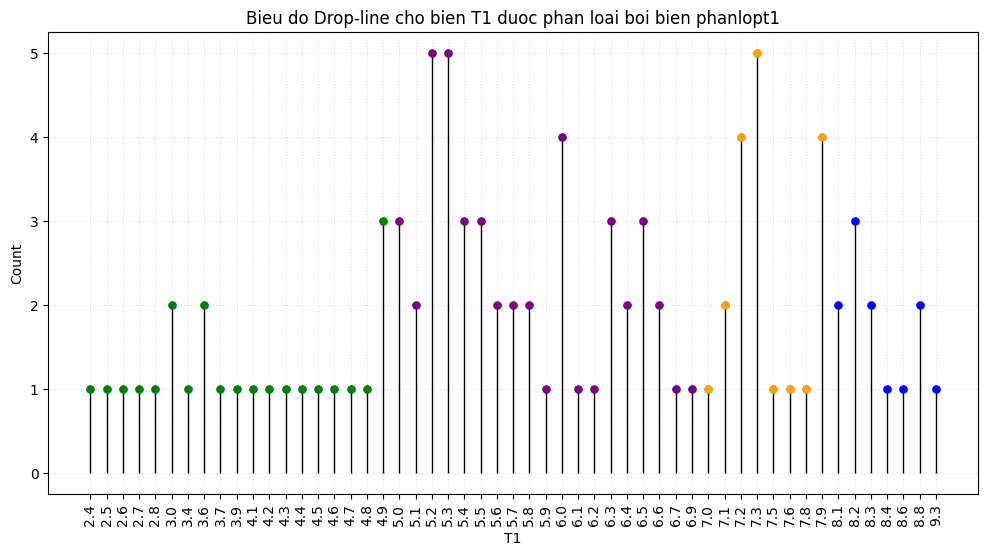

In [57]:
#Câu 5: Vẽ biểu đồ Drop-line cho biến T1 phân loại bởi phanlopt1
print("\n--- Câu 5: Biểu đồ Drop-line cho T1 theo phanlopt1 ---")
plt.figure(figsize=(12, 6))

cac_muc_diem = thong_ke_t1.index
so_luong_diem = thong_ke_t1.values

mau_cham_tron = []
for diem in cac_muc_diem:
    if diem < 5:
        mau_cham_tron.append('green')
    elif diem < 7:
        mau_cham_tron.append('purple')
    elif diem < 8:
        mau_cham_tron.append('orange')
    else:
        mau_cham_tron.append('blue')

markerline, stemlines, baseline = plt.stem(cac_muc_diem.astype(str), so_luong_diem, basefmt=" ")
plt.setp(stemlines, 'linewidth', 1, 'color', 'black')
plt.setp(markerline, 'markersize', 5)

for i, mau in enumerate(mau_cham_tron):
    plt.plot(cac_muc_diem.astype(str)[i], so_luong_diem[i], marker='o', color=mau, markersize=5)

plt.title("Bieu do Drop-line cho bien T1 duoc phan loai boi bien phanlopt1")
plt.xlabel("T1")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

In [58]:
# ==========================================================
# PHẦN 5: MÔ TẢ DỮ LIỆU VÀ KHẢO SÁT DẠNG PHÂN PHỐI
# ==========================================================
print("\n" + "="*60)
print("PHẦN 5: MÔ TẢ DỮ LIỆU VÀ KHẢO SÁT DẠNG PHÂN PHỐI")
print("="*60)


PHẦN 5: MÔ TẢ DỮ LIỆU VÀ KHẢO SÁT DẠNG PHÂN PHỐI



--- Câu 1: Mô tả và khảo sát phân phối cho biến T1 ---
count    100.000000
mean       5.946000
std        1.608338
min        2.400000
25%        5.000000
50%        5.850000
75%        7.200000
max        9.300000
Name: T1, dtype: float64
Trung vi (Median): 5.85
Yeu vi (Mode): 5.2
Do lech (Skewness): -0.17824317486762223
Do nhon (Kurtosis): -0.48010360836580634


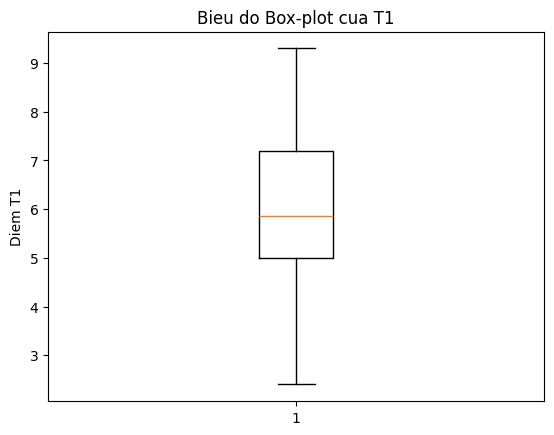

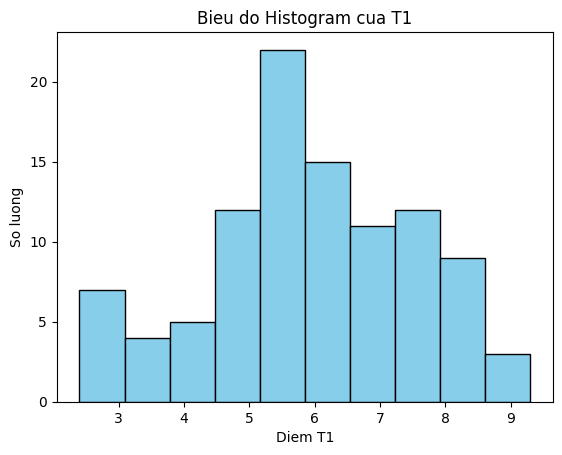

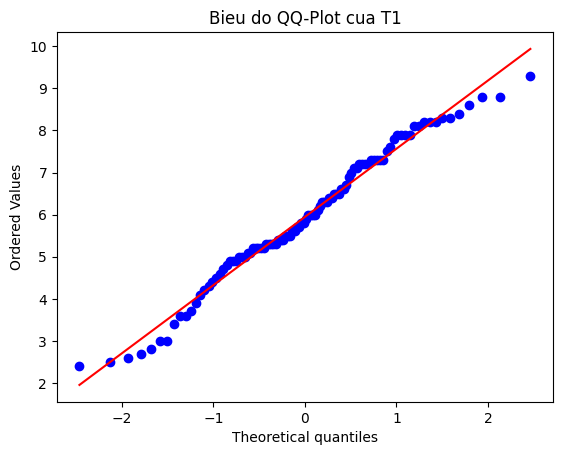

In [59]:
# Câu 1: Mô tả và khảo sát phân phối cho biến T1
print("\n--- Câu 1: Mô tả và khảo sát phân phối cho biến T1 ---")
print(df['T1'].describe())
print("Trung vi (Median):", df['T1'].median())
print("Yeu vi (Mode):", df['T1'].mode()[0])
print("Do lech (Skewness):", df['T1'].skew())
print("Do nhon (Kurtosis):", df['T1'].kurt())

plt.boxplot(df['T1'])
plt.title("Bieu do Box-plot cua T1")
plt.ylabel("Diem T1")
plt.show()

plt.hist(df['T1'], bins=10, edgecolor='black', color='skyblue')
plt.title("Bieu do Histogram cua T1")
plt.xlabel("Diem T1")
plt.ylabel("So luong")
plt.show()

stats.probplot(df['T1'], dist="norm", plot=plt)
plt.title("Bieu do QQ-Plot cua T1")
plt.show()


--- Câu 2: Khảo sát phân phối T1 theo từng nhóm phanlopT1 ---


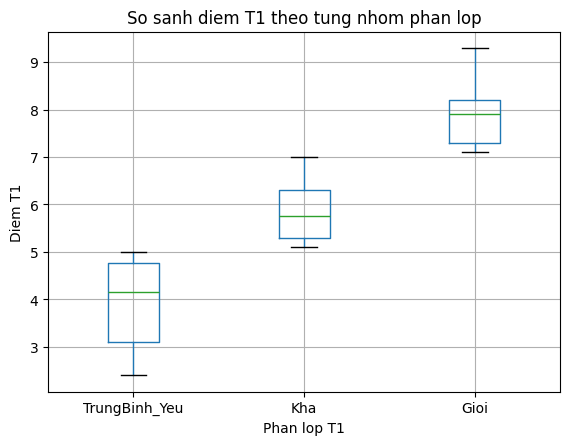

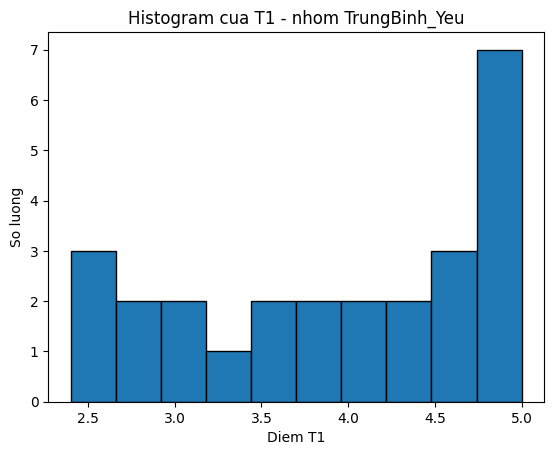

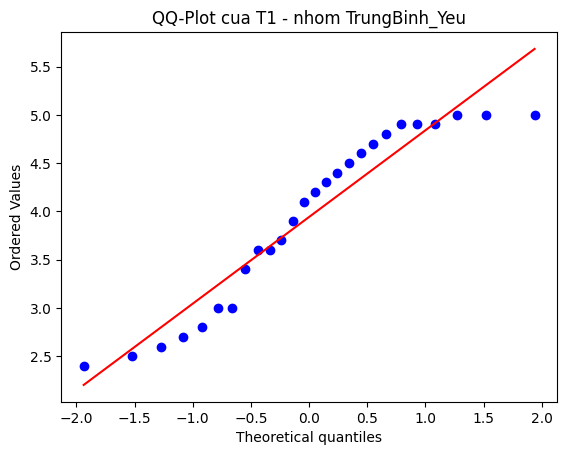

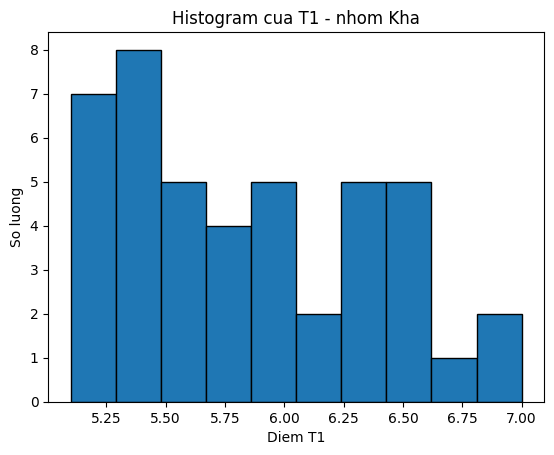

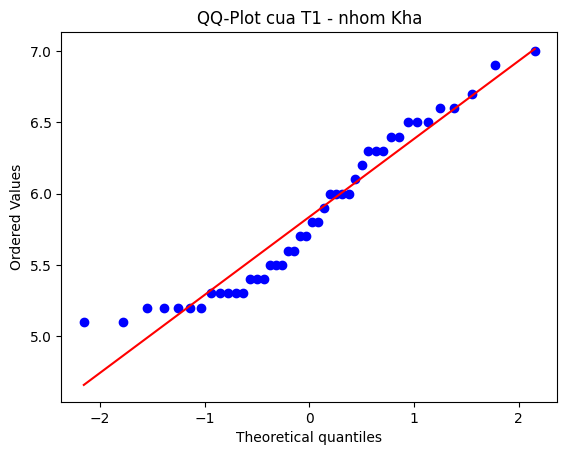

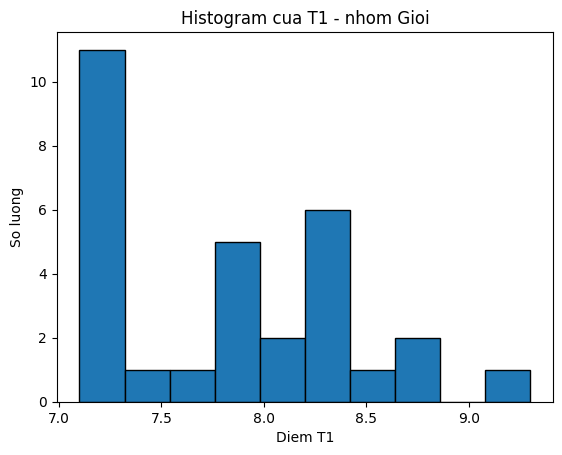

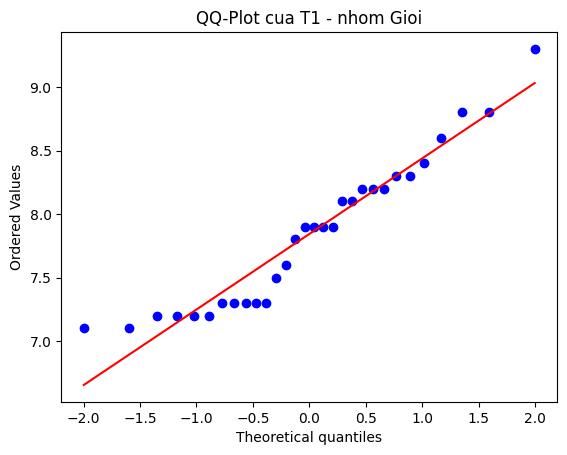

In [60]:
# Câu 2: Mô tả và khảo sát phân phối cho biến T1 trên từng nhóm phân lớp (phanlopT1)
print("\n--- Câu 2: Khảo sát phân phối T1 theo từng nhóm phanlopT1 ---")
df['phanlopT1'] = pd.cut(df['T1'], bins=[0, 5, 7, 10], labels=['TrungBinh_Yeu', 'Kha', 'Gioi'])
df.boxplot(column='T1', by='phanlopT1')
plt.title("So sanh diem T1 theo tung nhom phan lop")
plt.suptitle("")
plt.ylabel("Diem T1")
plt.xlabel("Phan lop T1")
plt.show()

for nhom in df['phanlopT1'].cat.categories:
    du_lieu_nhom = df[df['phanlopT1'] == nhom]['T1']
    if not du_lieu_nhom.empty:
        plt.hist(du_lieu_nhom, bins=10, edgecolor='black')
        plt.title(f"Histogram cua T1 - nhom {nhom}")
        plt.xlabel("Diem T1")
        plt.ylabel("So luong")
        plt.show()

        stats.probplot(du_lieu_nhom, dist="norm", plot=plt)
        plt.title(f"QQ-Plot cua T1 - nhom {nhom}")
        plt.show()


--- Câu 3: Khảo sát tương quan giữa DH1 và T1 ---
Hiep phuong sai (Covariance): 0.11283838383838381
He so tuong quan (Correlation): 0.04925439216104145


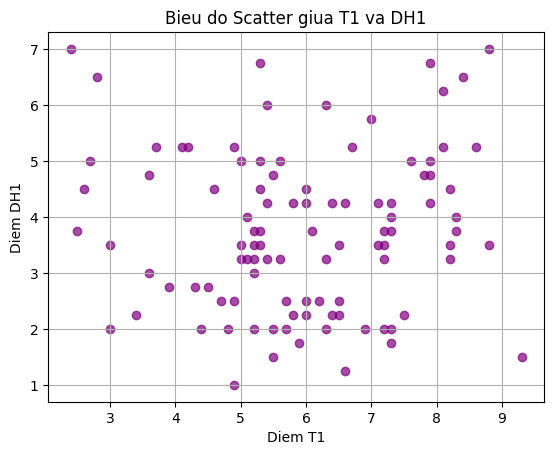

In [61]:
# Câu 3: Khảo sát tương quan giữa biến DH1 theo biến T1
print("\n--- Câu 3: Khảo sát tương quan giữa DH1 và T1 ---")
print("Hiep phuong sai (Covariance):", df['T1'].cov(df['DH1']))
print("He so tuong quan (Correlation):", df['T1'].corr(df['DH1']))

plt.scatter(df['T1'], df['DH1'], color='purple', alpha=0.7)
plt.title("Bieu do Scatter giua T1 va DH1")
plt.xlabel("Diem T1")
plt.ylabel("Diem DH1")
plt.grid(True)
plt.show()


--- Câu 3: Khảo sát tương quan giữa DH1 và T1 ---
Hiep phuong sai (Covariance): 0.11283838383838381
He so tuong quan (Correlation): 0.04925439216104145


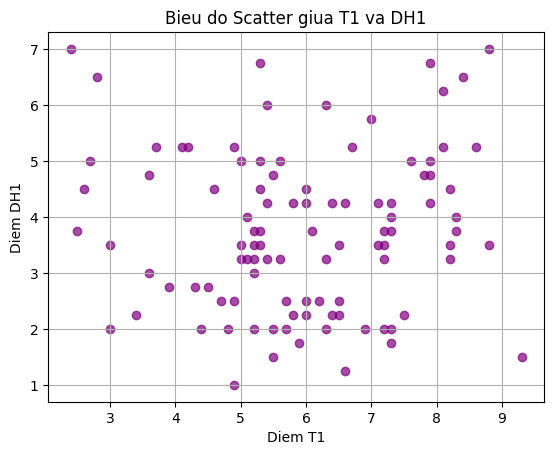

In [62]:
# Câu 3: Khảo sát tương quan giữa biến DH1 theo biến T1
print("\n--- Câu 3: Khảo sát tương quan giữa DH1 và T1 ---")
print("Hiep phuong sai (Covariance):", df['T1'].cov(df['DH1']))
print("He so tuong quan (Correlation):", df['T1'].corr(df['DH1']))

plt.scatter(df['T1'], df['DH1'], color='purple', alpha=0.7)
plt.title("Bieu do Scatter giua T1 va DH1")
plt.xlabel("Diem T1")
plt.ylabel("Diem DH1")
plt.grid(True)
plt.show()


--- Câu 5: Khảo sát tương quan giữa DH1, DH2, DH3 ---
Ma tran Hiep phuong sai:
          DH1       DH2       DH3
DH1  2.028939  0.053081  0.027778
DH2  0.053081  1.123712 -0.101010
DH3  0.027778 -0.101010  1.083965

Ma tran Tuong quan:
          DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000


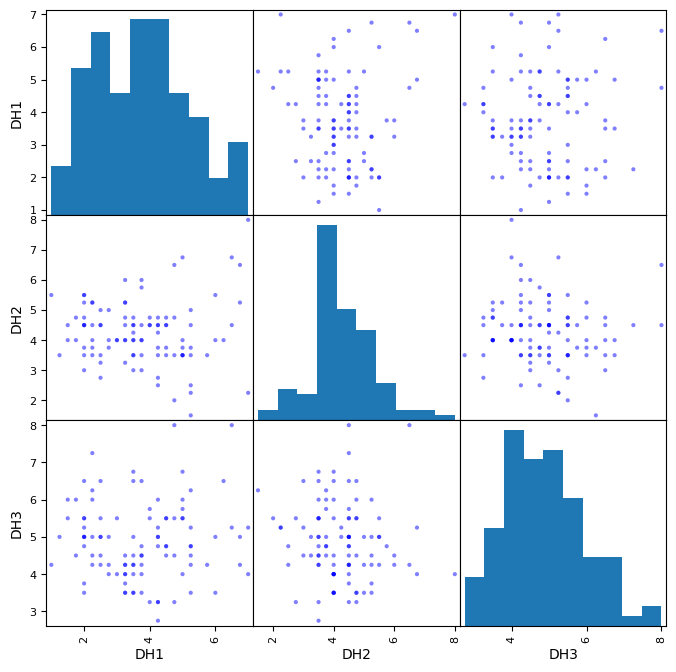

In [63]:
# Câu 5: Khảo sát tương quan giữa các biến DH1, DH2, DH3
print("\n--- Câu 5: Khảo sát tương quan giữa DH1, DH2, DH3 ---")
nhom_ba_bien = df[['DH1', 'DH2', 'DH3']]
print("Ma tran Hiep phuong sai:")
print(nhom_ba_bien.cov())
print("\nMa tran Tuong quan:")
print(nhom_ba_bien.corr())

scatter_matrix(nhom_ba_bien, figsize=(8, 8), diagonal='hist', c='blue')
plt.show()